In [41]:
import geopandas as gpd
import pandas as pd
import os
from haversine import haversine, Unit
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Polygon

In [8]:
input_file_path = os.path.join('..', '..','01_data', '01_input_data', '02_processed')
input_shape_EU_file_path = os.path.join('..', '..','01_data', '01_input_data', '01_raw', 'eu_shape_file')
shape_file_EU = '/NUTS_RG_20M_2021_3035.shp'

#get path
current_folder_path = os.getcwd()
parent_folder_path = os.path.abspath(os.path.join(current_folder_path, os.pardir))

shape_EU = gpd.read_file(input_shape_EU_file_path + shape_file_EU)

In [30]:
shape_EU.head(25)

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,FR,0,FR,France,France,0.0,0,0,FR,"MULTIPOLYGON (((9954236.116 -3059379.316, 9961..."
1,HR,0,HR,Hrvatska,Hrvatska,0.0,0,0,HR,"MULTIPOLYGON (((4827385.889 2618351.326, 48483..."
2,HU,0,HU,Magyarország,Magyarország,0.0,0,0,HU,"POLYGON ((5214660.069 2880853.832, 5216710.220..."
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"POLYGON ((5129579.170 2204098.752, 5148385.473..."
4,AT,0,AT,Österreich,Österreich,0.0,0,0,AT,"POLYGON ((4742889.368 2876362.725, 4783217.798..."
5,BE,0,BE,Belgique/België,Belgique/België,0.0,0,0,BE,"POLYGON ((3957506.818 3167694.476, 3964175.126..."
6,BG,0,BG,Bulgaria,България,0.0,0,0,BG,"POLYGON ((5363358.686 2390534.464, 5395245.631..."
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0.0,0,0,CH,"POLYGON ((4221123.476 2731035.919, 4230514.931..."
8,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"POLYGON ((6342668.882 1629618.498, 6342926.802..."
9,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((4645979.160 3093185.023, 4656689.778..."


In [31]:
countries_gdf = shape_EU

# Extract the relevant columns: Country names and geometry
countries_gdf = countries_gdf[['NAME_LATN', 'geometry']]

# Reproject to a projected coordinate system (e.g., UTM, EPSG:3035 for Europe)
countries_gdf = countries_gdf.to_crs(epsg=3035)

# Calculate centroids in the projected coordinate system (EPSG:3035)
countries_gdf['centroid'] = countries_gdf.geometry.centroid

# Reproject centroids back to geographic coordinates (EPSG:4326)
countries_gdf['centroid'] = countries_gdf['centroid'].to_crs(epsg=4326)

# Create a dictionary with country names and their centroid coordinates (latitude, longitude)
country_centroids = {row['NAME_LATN']: (row.centroid.y, row.centroid.x) for idx, row in countries_gdf.iterrows()}

# Example: list of connections (replace with your actual data)
connections = [("France", "Deutschland"), ('Deutschland', 'Österreich'), ('Deutschland', 'Česko'), ('Deutschland', 'España')]

# Calculate distances for connected countries
distances = []
for country1, country2 in connections:
    if country1 in country_centroids and country2 in country_centroids:
        coord1 = country_centroids[country1]
        coord2 = country_centroids[country2]
        distance = haversine(coord1, coord2, unit=Unit.KILOMETERS)
        distances.append((country1, country2, distance))

# Output the distances
for country1, country2, distance in distances:
    print(f"Distance between {country1} and {country2}: {distance:.2f} km")

Distance between France and Deutschland: 1619.30 km
Distance between Deutschland and Österreich: 470.88 km
Distance between Deutschland and Česko: 381.09 km
Distance between Deutschland and España: 1623.06 km


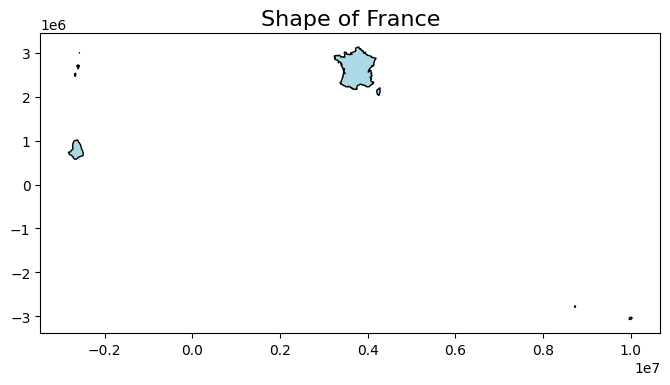

In [33]:

# Filter the GeoDataFrame to get only France
france_gdf = countries_gdf[countries_gdf['NAME_LATN'] == 'France']

# Plot the shape of France
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
france_gdf.plot(ax=ax, color='lightblue', edgecolor='black')
ax.set_title("Shape of France", fontsize=16)
plt.show()

C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_15296\1361388800.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  france_centroid = france_gdf.geometry.centroid.iloc[0]


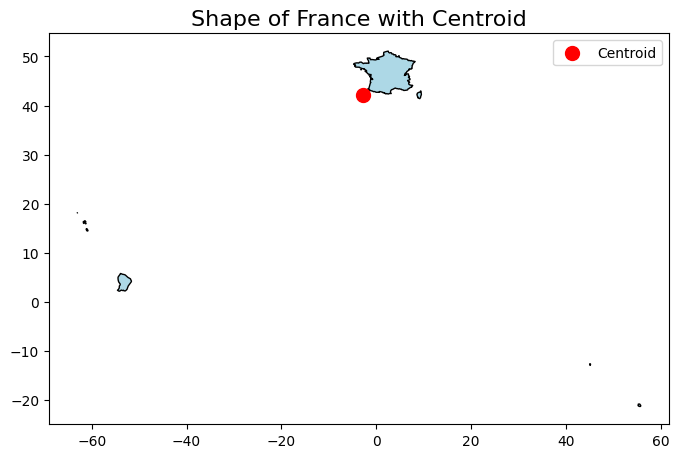

In [34]:
# Filter the GeoDataFrame to get only France
france_gdf = countries_gdf[countries_gdf['NAME_LATN'] == 'France']

# Ensure the GeoDataFrame is in EPSG:4326 (WGS84)
france_gdf = france_gdf.to_crs(epsg=4326)

# Calculate the centroid of France
france_centroid = france_gdf.geometry.centroid.iloc[0]

# Plot the shape of France and its centroid
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
france_gdf.plot(ax=ax, color='lightblue', edgecolor='black')
ax.scatter(france_centroid.x, france_centroid.y, color='red', marker='o', s=100, label='Centroid')
ax.set_title("Shape of France with Centroid", fontsize=16)
ax.legend()
plt.show()

In [40]:
# Get the geometry (MULTIPOLYGON) values for France
france_geometry = france_gdf['geometry'].iloc[0]

# Convert the MULTIPOLYGON to a string and print the full details
print(str(france_geometry))

MULTIPOLYGON (((55.214714260201475 -21.03851208596236, 55.273919700912415 -21.000572522645765, 55.28509578405292 -20.92360339391122, 55.32105184935725 -20.932164313266966, 55.450576288301065 -20.86976035777267, 55.6486224782131 -20.91395601020062, 55.708120433600605 -21.02544231709615, 55.83808178617596 -21.183548501003127, 55.804001638068996 -21.26176735771458, 55.810533391014864 -21.334801346208717, 55.77648814025877 -21.366239032658914, 55.64758725000677 -21.390765204928847, 55.460871266652205 -21.343370323469635, 55.33833057477387 -21.281508109368975, 55.29244816816127 -21.231229883802033, 55.28514422826285 -21.162203051601058, 55.214714260201475 -21.03851208596236)), ((45.221841863068995 -12.872266334405522, 45.15379843090704 -12.99411815594603, 45.10799040067808 -12.98680374965083, 45.1376483499344 -12.890775266011683, 45.093786606973005 -12.852457552755713, 45.1005609611113 -12.7660565749118, 45.04322329779649 -12.722851487755438, 45.09569413925607 -12.67002680741207, 45.1559477

<Axes: >

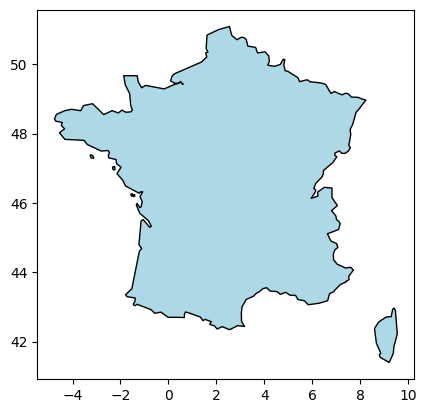

In [44]:
# Reproject to WGS84 if necessary
if countries_gdf.crs != "EPSG:4326":
    countries_gdf = countries_gdf.to_crs(epsg=4326)

# Filter the GeoDataFrame to get only France
france_gdf = countries_gdf[countries_gdf['NAME_LATN'] == 'France']

# Get the geometry (MULTIPOLYGON) of France
france_geometry = france_gdf['geometry'].iloc[0]

# Split the MULTIPOLYGON into individual POLYGON geometries
polygons = list(france_geometry.geoms)

# Filter polygons based on the bounding box for mainland France
mainland_polygons = [
    poly for poly in polygons if -5.5 <= poly.bounds[0] <= 9.5
    and 41.0 <= poly.bounds[1] <= 51.5
]

# Create a new MULTIPOLYGON for mainland France
mainland_france = MultiPolygon(mainland_polygons)

# Create a new GeoDataFrame for mainland France
mainland_france_gdf = gpd.GeoDataFrame(geometry=[mainland_france], crs="EPSG:4326")

# Plot mainland France
mainland_france_gdf.plot(color='lightblue', edgecolor='black')

In [43]:
mainland_france_gdf

,geometry
0,MULTIPOLYGON EMPTY


In [45]:
# Update the geometry in countries_gdf for France to the mainland geometry
countries_gdf.loc[countries_gdf['NAME_LATN'] == 'France', 'geometry'] = mainland_france

In [46]:
# Extract the relevant columns: Country names and geometry
countries_gdf = countries_gdf[['NAME_LATN', 'geometry']]

# Reproject to a projected coordinate system (e.g., UTM, EPSG:3035 for Europe)
countries_gdf = countries_gdf.to_crs(epsg=3035)

# Calculate centroids in the projected coordinate system (EPSG:3035)
countries_gdf['centroid'] = countries_gdf.geometry.centroid

# Reproject centroids back to geographic coordinates (EPSG:4326)
countries_gdf['centroid'] = countries_gdf['centroid'].to_crs(epsg=4326)

# Create a dictionary with country names and their centroid coordinates (latitude, longitude)
country_centroids = {row['NAME_LATN']: (row.centroid.y, row.centroid.x) for idx, row in countries_gdf.iterrows()}

# Example: list of connections (replace with your actual data)
connections = [("France", "Deutschland"), ('Deutschland', 'Österreich'), ('Deutschland', 'Česko'), ('Deutschland', 'España')]

# Calculate distances for connected countries
distances = []
for country1, country2 in connections:
    if country1 in country_centroids and country2 in country_centroids:
        coord1 = country_centroids[country1]
        coord2 = country_centroids[country2]
        distance = haversine(coord1, coord2, unit=Unit.KILOMETERS)
        distances.append((country1, country2, distance))

# Output the distances
for country1, country2, distance in distances:
    print(f"Distance between {country1} and {country2}: {distance:.2f} km")

Distance between France and Deutschland: 761.28 km
Distance between Deutschland and Österreich: 470.88 km
Distance between Deutschland and Česko: 381.09 km
Distance between Deutschland and España: 1623.06 km
